<a href="https://colab.research.google.com/github/sakibqureshi/Currency_Exchange_React/blob/main/NSL_Intrusion_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
train = pd.read_csv('/KDDTrain+.txt', header= None)
test = pd.read_csv('/KDDTest+.txt', header= None)
print("Train Shape",train.head())
print("Test Shape",test.head())
print("Train Shape",train.shape)
print("Test Shape",test.shape)

Train Shape    0    1         2   3    4     5   6   7   8   9   ...    33    34    35  \
0   0  tcp  ftp_data  SF  491     0   0   0   0   0  ...  0.17  0.03  0.17   
1   0  udp     other  SF  146     0   0   0   0   0  ...  0.00  0.60  0.88   
2   0  tcp   private  S0    0     0   0   0   0   0  ...  0.10  0.05  0.00   
3   0  tcp      http  SF  232  8153   0   0   0   0  ...  1.00  0.00  0.03   
4   0  tcp      http  SF  199   420   0   0   0   0  ...  1.00  0.00  0.00   

     36    37    38    39    40       41  42  
0  0.00  0.00  0.00  0.05  0.00   normal  20  
1  0.00  0.00  0.00  0.00  0.00   normal  15  
2  0.00  1.00  1.00  0.00  0.00  neptune  19  
3  0.04  0.03  0.01  0.00  0.01   normal  21  
4  0.00  0.00  0.00  0.00  0.00   normal  21  

[5 rows x 43 columns]
Test Shape    0     1         2     3      4   5   6   7   8   9   ...    33    34    35  \
0   0   tcp   private   REJ      0   0   0   0   0   0  ...  0.04  0.06  0.00   
1   0   tcp   private   REJ      0   0   

In [ ]:
column_names = [
"duration","protocol_type","service","flag","src_bytes","dst_bytes",
"land","wrong_fragment","urgent","hot","num_failed_logins",
"logged_in","num_compromised","root_shell","su_attempted","num_root",
"num_file_creations","num_shells","num_access_files","num_outbound_cmds",
"is_host_login","is_guest_login","count","srv_count","serror_rate",
"srv_serror_rate","rerror_rate","srv_rerror_rate","same_srv_rate",
"diff_srv_rate","srv_diff_host_rate","dst_host_count","dst_host_srv_count",
"dst_host_same_srv_rate","dst_host_diff_srv_rate",
"dst_host_same_src_port_rate","dst_host_srv_diff_host_rate",
"dst_host_serror_rate","dst_host_srv_serror_rate",
"dst_host_rerror_rate","dst_host_srv_rerror_rate","label","difficulty"
]

train.columns = column_names
test.columns = column_names

train.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [ ]:
train.drop('difficulty',axis=1,inplace=True)
test.drop('difficulty',axis=1,inplace=True)

In [ ]:
X_train = train.drop("label", axis=1)
y_train = train["label"]

X_test = test.drop("label", axis=1)
y_test = test["label"]

In [ ]:
y_train = y_train.apply(lambda x: 0 if x == "normal" else 1)
y_test = y_test.apply(lambda x: 0 if x == "normal" else 1)

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in X_train.columns:
    if X_train[col].dtype == 'object':
        X_train[col] = le.fit_transform(X_train[col])
        X_test[col] = le.transform(X_test[col])

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

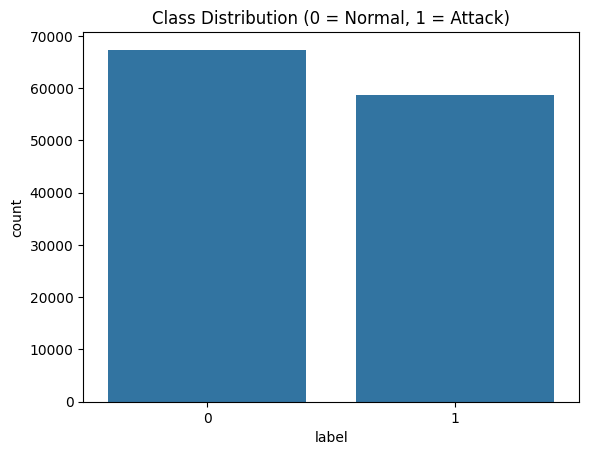

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=y_train)
plt.title("Class Distribution (0 = Normal, 1 = Attack)")
plt.show()

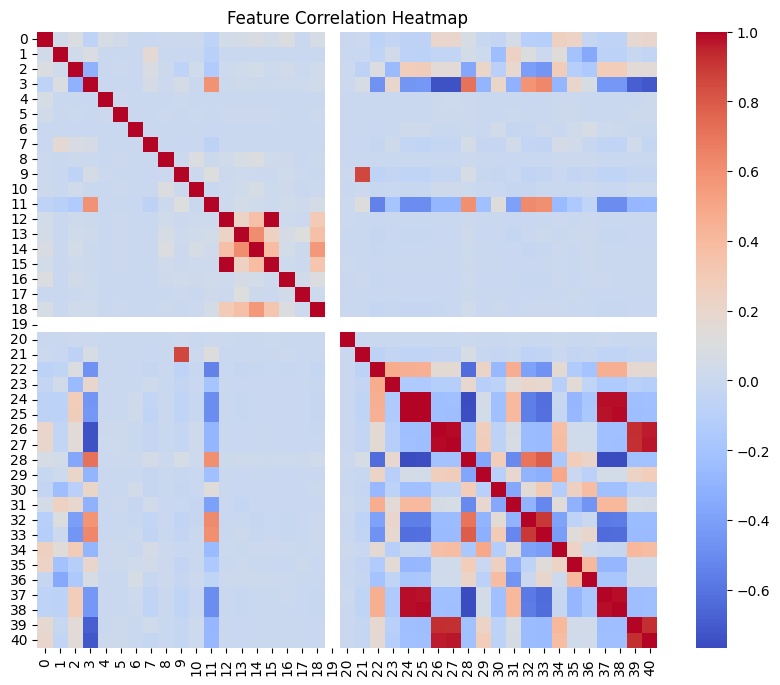

In [ ]:
import pandas as pd

corr = pd.DataFrame(X_train).corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

In [ ]:
train["label"].value_counts()

,count
label,
normal,67343
neptune,41214
satan,3633
ipsweep,3599
portsweep,2931
smurf,2646
nmap,1493
back,956
teardrop,892


In [ ]:
!pip install pyswarms

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 3.5 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pyswarms as ps
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
def fitness_function(particles):
    scores = []

    for particle in particles:
        # Convert to boolean mask
        selected = particle > 0.5

        # If no feature selected
        if selected.sum() == 0:
            scores.append(1)
            continue

        X_selected = X_train[:, selected]

        model = RandomForestClassifier(n_estimators=50, random_state=42)

        score = cross_val_score(model, X_selected, y_train, cv=3).mean()

        # We minimize, so use (1 - accuracy)
        scores.append(1 - score)

    return np.array(scores)

In [ ]:
options = {'c1': 0.5, 'c2': 0.3, 'w': 0.9}

optimizer = ps.single.GlobalBestPSO(
    n_particles=10,
    dimensions=X_train.shape[1],
    options=options
)

cost, pos = optimizer.optimize(fitness_function, iters=10)

2026-05-04 15:19:41,205 - pyswarms.single.global_best - INFO - Optimize for 10 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
pyswarms.single.global_best: 100%|██████████|10/10, best_cost=0.0011
2026-05-04 15:39:40,539 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.0010954728394180213, best pos: [1.09834085 2.73921092 2.49404333 1.37301324 0.99208566 1.41303481
 1.0427908  0.27849881 1.00531154 1.0876352  0.6699027  1.20503293
 0.94763778 2.25310035 2.59532058 0.64105984 2.450454   1.09412368
 1.25474583 2.04592517 0.9393693  1.1314518  1.38166362 2.27390246
 2.52629949 0.59401382 0.09218047 0.80476056 0.46444215 1.86479383
 1.26381486 1.89170374 0.99748699 0.99590784 1.49545485 1.28672701
 1.25137183 2.25786933 2.30532325 1.51569258 2.64452746]


In [ ]:
selected_features = pos > 0.5

X_train_pso = X_train[:, selected_features]
X_test_pso = X_test[:, selected_features]

print("Original features:", X_train.shape[1])
print("Selected features:", X_train_pso.shape[1])

Original features: 41
Selected features: 38


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Model
rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Train
rf.fit(X_train, y_train)

# Predict
y_pred = rf.predict(X_test)
print("WITHOUT PSO")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

WITHOUT PSO
Accuracy: 0.7704488999290277
Precision: 0.9662688748173405
Recall: 0.6183277487726954
F1 Score: 0.7540983606557377
Confusion Matrix:
 [[9434  277]
 [4898 7935]]


In [ ]:
rf_pso = RandomForestClassifier(n_estimators=100, random_state=42)

rf_pso.fit(X_train_pso, y_train)

y_pred_pso = rf_pso.predict(X_test_pso)
print("WITH PSO")
print("Accuracy:", accuracy_score(y_test, y_pred_pso))
print("Precision:", precision_score(y_test, y_pred_pso))
print("Recall:", recall_score(y_test, y_pred_pso))
print("F1 Score:", f1_score(y_test, y_pred_pso))

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_pso))

WITH PSO
Accuracy: 0.7692512420156139
Precision: 0.9660437278612435
Recall: 0.6163017221226526
F1 Score: 0.7525214081826832
Confusion Matrix:
 [[9433  278]
 [4924 7909]]


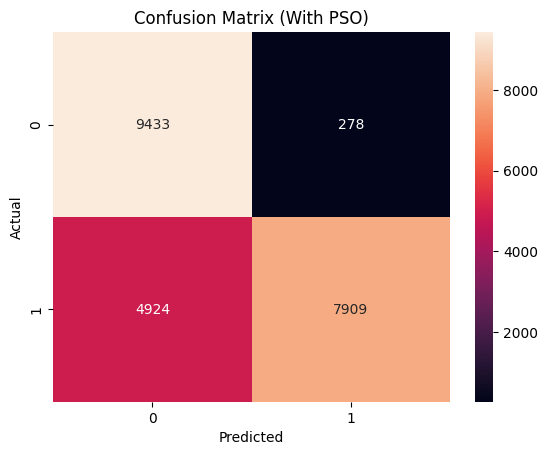

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_pso)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix (With PSO)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()